# Phase 6 — Regional Cluster Analysis

This notebook extends Phase 5 by adding a **regional and spatial interpretation layer** to the municipal typology workflow.  
Rather than treating municipalities only as isolated observations, it asks whether municipal typologies organize into broader **regional systems** across Puerto Rico.

This revised workflow does four things:

1. **Carries forward Phase 5 outputs explicitly**, including the preferred municipal cluster solution and vulnerability score.
2. **Defines regions transparently** using a fixed municipality-to-region mapping.
3. **Builds and validates region-level systems** using aggregated structural profiles and clustering diagnostics.
4. **Checks spatial coherence** using adjacency-based diagnostics and optional spatial autocorrelation tests when the required packages are available.


## 1. Load libraries and Phase 5 outputs


In [1]:
from pathlib import Path
import json
import unicodedata

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.preprocessing import StandardScaler

analysis_dir = Path(".")

typology_candidates = [
    analysis_dir / "municipal_typologies_latest_year.csv",
    analysis_dir / "phase5_municipal_typologies_latest_year.csv",
]
summary_candidates = [
    analysis_dir / "phase5_typology_summary.json",
    analysis_dir / "phase5_summary.json",
]

typology_path = next((p for p in typology_candidates if p.exists()), None)
summary_path = next((p for p in summary_candidates if p.exists()), None)

if typology_path is None:
    raise FileNotFoundError(
        "Could not find a Phase 5 municipal typology export. "
        "Expected something like municipal_typologies_latest_year.csv in the current directory."
    )

df = pd.read_csv(typology_path)

if summary_path is not None:
    with open(summary_path, "r") as f:
        phase5_summary = json.load(f)
    print(f"Loaded Phase 5 summary: {summary_path.name}")
else:
    phase5_summary = {}
    print("Phase 5 summary JSON not found. Continuing with the CSV only.")

def strip_accents(value):
    value = str(value).strip()
    return "".join(
        ch for ch in unicodedata.normalize("NFKD", value)
        if not unicodedata.combining(ch)
    )

def normalize_name(value):
    return strip_accents(value).lower().replace("-", " ").replace("  ", " ").strip()

if "municipio" not in df.columns:
    raise ValueError("Expected a 'municipio' column in the Phase 5 typology export.")

df["municipio_norm"] = df["municipio"].map(normalize_name)

cluster_candidates = []
for col in df.columns:
    if col.startswith("kmeans_cluster_"):
        try:
            k = int(col.split("_")[-1])
            cluster_candidates.append((k, col))
        except ValueError:
            pass

cluster_candidates = sorted(cluster_candidates)
cluster_cols = [col for _, col in cluster_candidates]

preferred_k = None
for key in ["preferred_primary_k", "selected_primary_k", "primary_k", "chosen_k"]:
    if key in phase5_summary:
        try:
            preferred_k = int(phase5_summary[key])
            break
        except (TypeError, ValueError):
            pass

primary_cluster_col = None
if preferred_k is not None and f"kmeans_cluster_{preferred_k}" in df.columns:
    primary_cluster_col = f"kmeans_cluster_{preferred_k}"
elif "kmeans_cluster" in df.columns:
    primary_cluster_col = "kmeans_cluster"
elif cluster_candidates:
    primary_cluster_col = cluster_candidates[0][1]

if primary_cluster_col is None:
    raise ValueError("Could not detect a municipal K-means cluster column from Phase 5.")

print("Phase 5 dataset shape:", df.shape)
print("Primary municipal cluster column:", primary_cluster_col)
print("Other detected cluster columns:", cluster_cols if cluster_cols else "None")
df.head()


Loaded Phase 5 summary: phase5_typology_summary.json
Phase 5 dataset shape: (78, 17)
Primary municipal cluster column: kmeans_cluster
Other detected cluster columns: ['kmeans_cluster_2', 'kmeans_cluster_3', 'kmeans_cluster_4']


,municipio,year,vulnerability_index,vulnerability_score_0_1,kmeans_cluster,hier_cluster,typology_label,kmeans_cluster_2,kmeans_cluster_3,kmeans_cluster_4,median_income_real,income_growth,max_seismic_mag,lag_violent_crime_rate,lag_property_crime_rate,lag_pop_change_1,municipio_norm
0,Adjuntas,2024,0.551093,1.000000,0,1,"Higher-vulnerability, lower-income declining m...",0,2,1,20352.27,2.060950,0.506484,0.166898,0.834492,0.016693,adjuntas
1,Aguada,2024,0.402057,0.686009,0,1,"Higher-vulnerability, lower-income declining m...",0,1,2,22384.47,-3.731612,-0.000000,0.131912,0.422119,-0.247381,aguada
2,Aguadilla,2024,0.299884,0.447936,0,1,"Higher-vulnerability, lower-income declining m...",0,2,1,22425.08,5.529888,0.503083,0.220240,1.027787,-0.485827,aguadilla
3,Aguas Buenas,2024,0.342103,0.546310,0,1,"Higher-vulnerability, lower-income declining m...",0,1,2,24020.03,0.221012,-0.000000,0.418620,0.293034,-1.027511,aguas buenas
4,Aibonito,2024,0.365335,0.600442,0,1,"Higher-vulnerability, lower-income declining m...",0,1,2,22637.46,-2.733270,-0.000000,0.243803,0.528241,0.223987,aibonito


## 2. Define the municipality-to-region mapping

For this phase, **regions are defined geographically rather than estimated statistically**.  
That is important: the manual mapping below creates interpretable macro-regions first, and the clustering step later asks whether these regions themselves organize into broader **regional systems** based on their structural profiles.

This keeps the notebook conceptually tied to Phase 5:

- **Phase 5:** municipality-level structural typologies  
- **Phase 6:** region-level organization of those municipal typologies


In [2]:
region_map = {
    # Metro
    "San Juan": "Metro",
    "Bayamón": "Metro",
    "Carolina": "Metro",
    "Cataño": "Metro",
    "Guaynabo": "Metro",
    "Toa Alta": "Metro",
    "Toa Baja": "Metro",
    "Trujillo Alto": "Metro",

    # North
    "Arecibo": "North",
    "Barceloneta": "North",
    "Camuy": "North",
    "Dorado": "North",
    "Florida": "North",
    "Hatillo": "North",
    "Manatí": "North",
    "Quebradillas": "North",
    "Vega Alta": "North",
    "Vega Baja": "North",

    # South
    "Arroyo": "South",
    "Coamo": "South",
    "Guayama": "South",
    "Guayanilla": "South",
    "Juana Díaz": "South",
    "Patillas": "South",
    "Peñuelas": "South",
    "Ponce": "South",
    "Salinas": "South",
    "Santa Isabel": "South",
    "Villalba": "South",
    "Yauco": "South",

    # West
    "Aguada": "West",
    "Aguadilla": "West",
    "Añasco": "West",
    "Cabo Rojo": "West",
    "Guánica": "West",
    "Hormigueros": "West",
    "Isabela": "West",
    "Lajas": "West",
    "Las Marías": "West",
    "Maricao": "West",
    "Mayagüez": "West",
    "Moca": "West",
    "Rincón": "West",
    "Sabana Grande": "West",
    "San Germán": "West",
    "San Sebastián": "West",

    # East
    "Canóvanas": "East",
    "Ceiba": "East",
    "Fajardo": "East",
    "Humacao": "East",
    "Juncos": "East",
    "Las Piedras": "East",
    "Loíza": "East",
    "Luquillo": "East",
    "Maunabo": "East",
    "Naguabo": "East",
    "Río Grande": "East",
    "San Lorenzo": "East",
    "Yabucoa": "East",
    "Caguas": "East",
    "Gurabo": "East",
    "Culebra": "East",
    "Vieques": "East",

    # Central Mountains
    "Adjuntas": "Central Mountains",
    "Aguas Buenas": "Central Mountains",
    "Aibonito": "Central Mountains",
    "Barranquitas": "Central Mountains",
    "Cayey": "Central Mountains",
    "Ciales": "Central Mountains",
    "Cidra": "Central Mountains",
    "Comerío": "Central Mountains",
    "Corozal": "Central Mountains",
    "Jayuya": "Central Mountains",
    "Lares": "Central Mountains",
    "Morovis": "Central Mountains",
    "Naranjito": "Central Mountains",
    "Orocovis": "Central Mountains",
    "Utuado": "Central Mountains",
}


## 3. Apply the regional mapping and verify coverage


In [3]:
region_map_norm = {normalize_name(k): v for k, v in region_map.items()}
df["region"] = df["municipio_norm"].map(region_map_norm)

missing_region = sorted(df.loc[df["region"].isna(), "municipio"].tolist())

print("Municipalities in Phase 5 export:", len(df))
print("Mapped to regions:", df["region"].notna().sum())
print("Unmatched municipalities:", len(missing_region))
missing_region


Municipalities in Phase 5 export: 78
Mapped to regions: 78
Unmatched municipalities: 0


[]

## 4. Region counts and the Phase 5 typology mix within each region

This section makes the Phase 5 → Phase 6 transition explicit by showing how the preferred municipal typology is distributed across the manually defined regions.


In [4]:
region_counts = df["region"].value_counts(dropna=False).sort_index()
region_counts


region
Central Mountains    15
East                 17
Metro                 8
North                10
South                12
West                 16
Name: count, dtype: int64

In [5]:
region_cluster_counts = pd.crosstab(df["region"], df[primary_cluster_col])
region_cluster_shares = pd.crosstab(df["region"], df[primary_cluster_col], normalize="index").round(3)

display(region_cluster_counts)
display(region_cluster_shares)


kmeans_cluster,0,1
region,,
Central Mountains,13,2
East,5,12
Metro,0,8
North,2,8
South,10,2
West,16,0


kmeans_cluster,0,1
region,,
Central Mountains,0.867,0.133
East,0.294,0.706
Metro,0.000,1.000
North,0.200,0.800
South,0.833,0.167
West,1.000,0.000


In [6]:
region_typology = None
if "typology_label" in df.columns:
    region_typology = pd.crosstab(df["region"], df["typology_label"])
    display(region_typology)
else:
    print("No typology_label column found; continuing without planner-facing typology labels.")


typology_label,"Higher-vulnerability, lower-income declining municipalities","Relatively stable, higher-income municipalities"
region,,
Central Mountains,13,2
East,5,12
Metro,0,8
North,2,8
South,10,2
West,16,0


## 5. Regional composition visuals

These plots restore the visual summary layer from the original notebook while keeping the improved Phase 6 workflow.

The first figure shows how the preferred Phase 5 municipal clusters are distributed across the manually defined regions.  
The second summarizes average vulnerability by region.


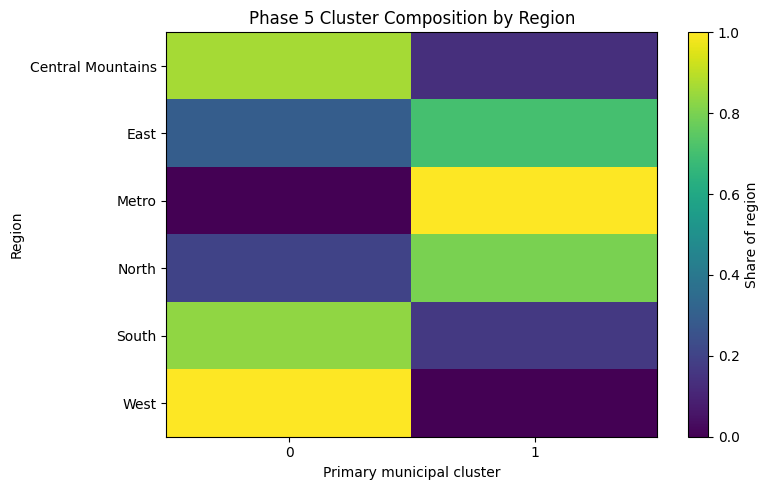

In [7]:
plt.figure(figsize=(8, 5))
plt.imshow(region_cluster_shares.values, aspect="auto")
plt.colorbar(label="Share of region")
plt.xticks(range(region_cluster_shares.shape[1]), region_cluster_shares.columns)
plt.yticks(range(region_cluster_shares.shape[0]), region_cluster_shares.index)
plt.title("Phase 5 Cluster Composition by Region")
plt.xlabel("Primary municipal cluster")
plt.ylabel("Region")
plt.tight_layout()
plt.show()

,mean,median,min,max,count
region,,,,,
Central Mountains,0.748,0.785,0.292,1.000,15
South,0.648,0.656,0.442,1.000,12
West,0.618,0.566,0.281,1.000,16
East,0.473,0.411,0.019,1.000,17
North,0.454,0.462,0.104,0.816,10
Metro,0.118,0.014,0.000,0.425,8


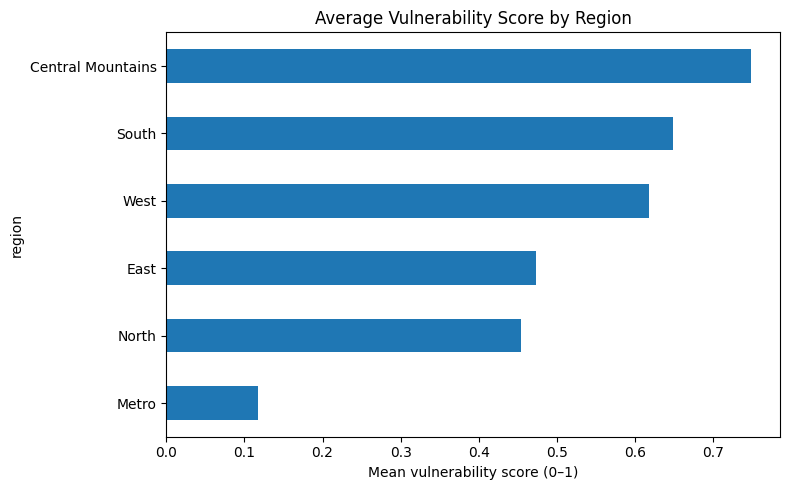

In [8]:
if "vulnerability_score_0_1" in df.columns:
    region_vulnerability = (
        df.groupby("region")["vulnerability_score_0_1"]
        .agg(["mean", "median", "min", "max", "count"])
        .sort_values("mean", ascending=False)
        .round(3)
    )
    display(region_vulnerability)

    plt.figure(figsize=(8, 5))
    region_vulnerability["mean"].sort_values().plot(kind="barh")
    plt.title("Average Vulnerability Score by Region")
    plt.xlabel("Mean vulnerability score (0–1)")
    plt.tight_layout()
    plt.show()
else:
    region_vulnerability = None
    print("No vulnerability_score_0_1 column found in Phase 5 output.")

## 6. Build region-level structural profiles

Each region is summarized using municipal averages and Phase 5 cluster shares.  
These region-level profiles are then used to estimate broader **regional systems**.

The idea is not to replace the geographic regions, but to ask whether the regions themselves fall into a smaller number of similar structural groupings.


In [9]:
profile_metric_candidates = [
    "vulnerability_score_0_1",
    "vulnerability_index",
    "median_income_real",
    "income_growth_pct",
    "target_pop_change",
    "lag_pop_change_1",
    "violent_rate",
    "property_rate",
    "eq_events_365d",
    "max_wind_knots",
]

profile_metric_cols = [c for c in profile_metric_candidates if c in df.columns]

region_profile = (
    df.groupby("region")[profile_metric_cols]
    .mean(numeric_only=True)
    .sort_index()
)

cluster_share_wide = pd.crosstab(df["region"], df[primary_cluster_col], normalize="index")
cluster_share_wide.columns = [f"{primary_cluster_col}_share_{int(c)}" for c in cluster_share_wide.columns]
cluster_share_wide = cluster_share_wide.sort_index()

region_profile = region_profile.join(cluster_share_wide, how="left")

if "typology_label" in df.columns:
    dominant_typology = (
        df.groupby(["region", "typology_label"]).size()
        .reset_index(name="n")
        .sort_values(["region", "n", "typology_label"], ascending=[True, False, True])
        .drop_duplicates("region")
        .set_index("region")["typology_label"]
        .rename("dominant_typology_label")
    )
    region_profile = region_profile.join(dominant_typology, how="left")

region_profile


,vulnerability_score_0_1,vulnerability_index,median_income_real,lag_pop_change_1,kmeans_cluster_share_0,kmeans_cluster_share_1,dominant_typology_label
region,,,,,,,
Central Mountains,0.748043,0.429632,23572.914667,-0.241778,0.866667,0.133333,"Higher-vulnerability, lower-income declining m..."
East,0.473188,0.311589,27588.331176,-0.139400,0.294118,0.705882,"Relatively stable, higher-income municipalities"
Metro,0.117877,0.122185,35898.862500,-0.586042,0.000000,1.000000,"Relatively stable, higher-income municipalities"
North,0.453714,0.302364,27019.198000,-0.206062,0.200000,0.800000,"Relatively stable, higher-income municipalities"
South,0.647790,0.385810,24084.488333,-1.072356,0.833333,0.166667,"Higher-vulnerability, lower-income declining m..."
West,0.617930,0.373810,22484.484375,-0.633988,1.000000,0.000000,"Higher-vulnerability, lower-income declining m..."


## 7. Validate region-level systems with clustering diagnostics

Unlike the original version of this notebook, region-level grouping is now **validated explicitly**.

The workflow below:
- standardizes the region-level profile matrix,
- evaluates multiple candidate values of k,
- checks silhouette scores and singleton clusters,
- chooses a **preferred primary region-system solution**, and
- measures seed stability with adjusted Rand index (ARI).

A slightly higher silhouette score is not treated as decisive if it requires a fragmented or singleton structure.


In [10]:
region_cluster_input = region_profile.select_dtypes(include=[np.number]).copy()

constant_region_cols = [
    c for c in region_cluster_input.columns
    if region_cluster_input[c].nunique(dropna=True) <= 1
]
if constant_region_cols:
    region_cluster_input = region_cluster_input.drop(columns=constant_region_cols)

if region_cluster_input.shape[1] == 0:
    raise ValueError("No usable numeric columns remain for region-level clustering.")

scaler = StandardScaler()
X_region = scaler.fit_transform(region_cluster_input)

candidate_ks = list(range(2, min(5, len(region_cluster_input) - 1) + 1))
region_cluster_eval = []

for k in candidate_ks:
    km = KMeans(n_clusters=k, n_init=50, random_state=42)
    labels = km.fit_predict(X_region)
    counts = pd.Series(labels).value_counts().sort_index()
    row = {
        "k": k,
        "inertia": float(km.inertia_),
        "min_cluster_size": int(counts.min()),
        "has_singleton": bool((counts == 1).any()),
    }
    row["silhouette"] = float(silhouette_score(X_region, labels)) if len(set(labels)) > 1 else np.nan
    region_cluster_eval.append(row)

region_cluster_eval = pd.DataFrame(region_cluster_eval).sort_values("k").reset_index(drop=True)
best_sil = region_cluster_eval["silhouette"].max()
preferred_margin = 0.02

eligible = region_cluster_eval[
    (~region_cluster_eval["has_singleton"]) &
    ((best_sil - region_cluster_eval["silhouette"]) <= preferred_margin)
].copy()

if len(eligible) > 0:
    preferred_region_k = int(eligible.sort_values(["k"]).iloc[0]["k"])
else:
    preferred_region_k = int(region_cluster_eval.sort_values(["silhouette", "k"], ascending=[False, True]).iloc[0]["k"])

best_region_k = int(region_cluster_eval.sort_values(["silhouette", "k"], ascending=[False, True]).iloc[0]["k"])

region_cluster_eval


,k,inertia,min_cluster_size,has_singleton,silhouette
0,2,12.426734,3,False,0.483417
1,3,4.052951,1,True,0.509372
2,4,1.282443,1,True,0.359290
3,5,0.099099,1,True,0.285257


In [11]:
seed_list = [7, 11, 19, 23, 29, 31, 37, 41, 43, 47]

seed_assignments = {}
for seed in seed_list:
    km = KMeans(n_clusters=preferred_region_k, n_init=50, random_state=seed)
    seed_assignments[seed] = km.fit_predict(X_region)

pairwise_ari = []
seed_keys = list(seed_assignments.keys())
for i in range(len(seed_keys)):
    for j in range(i + 1, len(seed_keys)):
        s1, s2 = seed_keys[i], seed_keys[j]
        pairwise_ari.append({
            "seed_a": s1,
            "seed_b": s2,
            "ari": adjusted_rand_score(seed_assignments[s1], seed_assignments[s2]),
        })

pairwise_ari_df = pd.DataFrame(pairwise_ari)
region_seed_stability = {
    "mean_ari": float(pairwise_ari_df["ari"].mean()) if len(pairwise_ari_df) else np.nan,
    "min_ari": float(pairwise_ari_df["ari"].min()) if len(pairwise_ari_df) else np.nan,
    "max_ari": float(pairwise_ari_df["ari"].max()) if len(pairwise_ari_df) else np.nan,
}

final_region_km = KMeans(n_clusters=preferred_region_k, n_init=100, random_state=42)
region_profile[f"region_system_k{preferred_region_k}"] = final_region_km.fit_predict(X_region)

print("Best silhouette k:", best_region_k)
print("Preferred primary region-system k:", preferred_region_k)
print("Region-system seed stability:", region_seed_stability)

display(pairwise_ari_df.head())
display(region_profile)


Best silhouette k: 3
Preferred primary region-system k: 3
Region-system seed stability: {'mean_ari': 1.0, 'min_ari': 1.0, 'max_ari': 1.0}


,seed_a,seed_b,ari
0,7,11,1.0
1,7,19,1.0
2,7,23,1.0
3,7,29,1.0
4,7,31,1.0


,vulnerability_score_0_1,vulnerability_index,median_income_real,lag_pop_change_1,kmeans_cluster_share_0,kmeans_cluster_share_1,dominant_typology_label,region_system_k3
region,,,,,,,,
Central Mountains,0.748043,0.429632,23572.914667,-0.241778,0.866667,0.133333,"Higher-vulnerability, lower-income declining m...",1
East,0.473188,0.311589,27588.331176,-0.139400,0.294118,0.705882,"Relatively stable, higher-income municipalities",2
Metro,0.117877,0.122185,35898.862500,-0.586042,0.000000,1.000000,"Relatively stable, higher-income municipalities",0
North,0.453714,0.302364,27019.198000,-0.206062,0.200000,0.800000,"Relatively stable, higher-income municipalities",2
South,0.647790,0.385810,24084.488333,-1.072356,0.833333,0.166667,"Higher-vulnerability, lower-income declining m...",1
West,0.617930,0.373810,22484.484375,-0.633988,1.000000,0.000000,"Higher-vulnerability, lower-income declining m...",1


## 8. Interpret region systems and map them back to municipalities

The estimated **region systems** are not replacements for the named regions.  
Instead, they provide a compact way to describe which geographic regions appear structurally similar after aggregating municipal vulnerability, income, momentum, crime, and cluster composition.


In [12]:
region_system_col = f"region_system_k{preferred_region_k}"
region_profile["region_system_label"] = (
    "Regional System " + region_profile[region_system_col].astype(int).astype(str)
)

region_system_lookup = region_profile[[region_system_col, "region_system_label"]].copy()
df = df.merge(
    region_system_lookup,
    left_on="region",
    right_index=True,
    how="left"
)

region_system_counts = (
    region_profile.groupby(region_system_col).size().rename("n_regions").to_frame()
)
region_system_counts


,n_regions
region_system_k3,
0,1
1,3
2,2


In [13]:
region_summary_cols = [c for c in [
    "vulnerability_score_0_1",
    "median_income_real",
    "target_pop_change",
    "lag_pop_change_1",
    "violent_rate",
    "property_rate",
    "eq_events_365d",
] if c in region_profile.columns]

region_system_profile = (
    region_profile.groupby(region_system_col)[region_summary_cols]
    .mean(numeric_only=True)
    .round(3)
)

region_system_profile


,vulnerability_score_0_1,median_income_real,lag_pop_change_1
region_system_k3,,,
0,0.118,35898.862,-0.586
1,0.671,23380.629,-0.649
2,0.463,27303.765,-0.173


## 9. Spatial coherence diagnostics

A regional analysis should not rely only on tabular summaries.  
This section adds a spatial layer:

- it loads municipality boundaries,
- merges the regional and typology outputs back onto geometry,
- computes simple **adjacency-based coherence metrics**, and
- optionally evaluates Moran's I for vulnerability when `libpysal` and `esda` are available.

If the required spatial files or packages are unavailable, the notebook continues without failing.


In [14]:
# --- Spatial dependencies and geometry loading ---
import json
from matplotlib.patches import Polygon as MplPolygon
from matplotlib.collections import PatchCollection

HAS_GEO = False
MAP_BACKEND = None
map_gdf = None
map_features = None
geo_path = None

geo_candidates = [
    analysis_dir / "pr_municipalities.geojson",
    analysis_dir / "data" / "pr_municipalities.geojson",
    analysis_dir / ".." / "data" / "tl_2022_72_cousub" / "pr_municipalities.geojson",
    analysis_dir / ".." / "data" / "pr_municipalities.geojson",
]
geo_path = next((p.resolve() for p in geo_candidates if p.exists()), None)

if geo_path is None:
    print("GeoJSON not found. Spatial diagnostics and maps will be skipped.")
else:
    print(f"Geometry candidate found: {geo_path}")
    try:
        import geopandas as gpd
        map_gdf = gpd.read_file(geo_path)
        HAS_GEO = True
        MAP_BACKEND = "geopandas"
        print("Spatial backend: geopandas")
        print("Geometry shape:", map_gdf.shape)
        display(map_gdf.head())
    except ImportError:
        print("geopandas not available in this kernel. Falling back to raw GeoJSON plotting.")
        with open(geo_path, "r", encoding="utf-8") as f:
            geojson_obj = json.load(f)
        map_features = geojson_obj.get("features", [])
        MAP_BACKEND = "geojson_fallback"
        print("Spatial backend: raw GeoJSON fallback")
        print("Feature count:", len(map_features))

def _detect_geo_name_from_properties(props):
    for candidate in ["municipio", "MUNICIPIO", "name", "NAME", "municipality", "Municipality", "NAMELSAD", "county_subdivision"]:
        if candidate in props and props[candidate]:
            return candidate
    return None

def _make_polygon_patches(geometry):
    patches = []
    if not geometry:
        return patches
    gtype = geometry.get("type")
    coords = geometry.get("coordinates", [])
    if gtype == "Polygon":
        polys = [coords]
    elif gtype == "MultiPolygon":
        polys = coords
    else:
        return patches

    for poly in polys:
        if not poly:
            continue
        outer = poly[0]
        if len(outer) >= 3:
            patches.append(MplPolygon(outer, closed=True))
    return patches

def _approx_label_point(geometry):
    if not geometry:
        return None
    pts = []
    gtype = geometry.get("type")
    coords = geometry.get("coordinates", [])
    if gtype == "Polygon":
        polys = [coords]
    elif gtype == "MultiPolygon":
        polys = coords
    else:
        return None
    for poly in polys:
        if poly and poly[0]:
            pts.extend(poly[0])
    if not pts:
        return None
    xs = [p[0] for p in pts]
    ys = [p[1] for p in pts]
    return (sum(xs)/len(xs), sum(ys)/len(ys))

def plot_geojson_map(
    feature_df,
    value_col=None,
    categorical=False,
    title="Map",
    cmap="viridis",
    category_colors=None,
    annotate_col=None,
    save_path=None,
    figsize=(12, 8),
):
    if feature_df is None or feature_df.empty:
        print("No fallback geometry available for plotting.")
        return

    fig, ax = plt.subplots(figsize=figsize)
    patches = []
    values = []
    facecolors = []

    for _, row in feature_df.iterrows():
        geom = row.get("geometry")
        row_patches = _make_polygon_patches(geom)
        if not row_patches:
            continue
        patches.extend(row_patches)

        if categorical:
            color = "#d9d9d9"
            if value_col is not None and category_colors is not None:
                color = category_colors.get(row.get(value_col), "#d9d9d9")
            facecolors.extend([color] * len(row_patches))
        else:
            val = row.get(value_col) if value_col is not None else np.nan
            values.extend([val] * len(row_patches))

    if categorical:
        pc = PatchCollection(patches, facecolor=facecolors, edgecolor="white", linewidth=0.4)
        ax.add_collection(pc)
    else:
        pc = PatchCollection(patches, cmap=cmap, edgecolor="white", linewidth=0.4)
        arr = np.array(values, dtype=float) if len(values) else np.array([])
        pc.set_array(arr)
        pc.set_clim(np.nanmin(arr) if len(arr) and np.isfinite(arr).any() else 0,
                    np.nanmax(arr) if len(arr) and np.isfinite(arr).any() else 1)
        ax.add_collection(pc)
        if len(values):
            fig.colorbar(pc, ax=ax, shrink=0.7)

    ax.autoscale()
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title, fontsize=16)

    if annotate_col is not None:
        for _, row in feature_df.iterrows():
            pt = _approx_label_point(row.get("geometry"))
            if pt is None:
                continue
            ax.text(
                pt[0], pt[1], str(row.get(annotate_col, "")),
                fontsize=8, ha="center", va="center", weight="bold",
                bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.7),
            )

    if categorical and category_colors:
        import matplotlib.patches as mpatches
        handles = [mpatches.Patch(color=color, label=str(cat)) for cat, color in category_colors.items()]
        ax.legend(handles=handles, loc="lower left", bbox_to_anchor=(1.01, 0.1), title=value_col)

    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
        print(f"Saved: {save_path}")
    plt.show()


Geometry candidate found: /Users/andreruiz/Library/Mobile Documents/com~apple~CloudDocs/Documents/Capstone/CAPSTONE_DATA_SCIENCE_RIVERARUIZ/data/tl_2022_72_cousub/pr_municipalities.geojson
Spatial backend: geopandas
Geometry shape: (78, 3)


,id,name,geometry
0,0,Añasco,"POLYGON ((-67.18903 18.26622, -67.18903 18.266..."
1,1,Adjuntas,"POLYGON ((-66.79774 18.13365, -66.80194 18.139..."
2,2,Aguada,"POLYGON ((-67.13012 18.31805, -67.13705 18.316..."
3,3,Aguadilla,"POLYGON ((-67.05623 18.46092, -67.07426 18.456..."
4,4,Aguas Buenas,"POLYGON ((-66.16881 18.22423, -66.17622 18.229..."


In [15]:
geo_muni_col = None

if MAP_BACKEND == "geopandas" and map_gdf is not None:
    possible_geo_name_cols = [c for c in map_gdf.columns if c.lower() in {"name", "municipio", "municipality", "namelsad", "county_subdivision"}]
    if not possible_geo_name_cols:
        raise ValueError(
            "Could not detect a municipality name column in the geometry file. "
            "Inspect map_gdf.columns and set geo_muni_col manually."
        )
    geo_muni_col = possible_geo_name_cols[0]
    print("Using geometry municipality column:", geo_muni_col)

    map_gdf["municipio_norm"] = map_gdf[geo_muni_col].map(normalize_name)
    merge_cols = [
        "municipio", "municipio_norm", "region", primary_cluster_col,
        region_system_col, "region_system_label"
    ]
    optional_merge_cols = [
        "typology_label", "vulnerability_score_0_1", "target_pop_change",
        "lag_pop_change_1", "median_income_real"
    ]
    merge_cols += [c for c in optional_merge_cols if c in df.columns and c not in merge_cols]
    map_gdf = map_gdf.merge(df[merge_cols].drop_duplicates("municipio_norm"), on="municipio_norm", how="left")

    print("Merged map shape:", map_gdf.shape)
    print("Rows with missing region after merge:", int(map_gdf["region"].isna().sum()))
    display(map_gdf[[geo_muni_col, "municipio", "region", region_system_col]].head())

elif MAP_BACKEND == "geojson_fallback" and map_features is not None:
    records = []
    for feat in map_features:
        props = feat.get("properties", {}) or {}
        if geo_muni_col is None:
            geo_muni_col = _detect_geo_name_from_properties(props)
        muni_name = props.get(geo_muni_col) if geo_muni_col is not None else None
        records.append({
            "geo_muni_raw": muni_name,
            "municipio_norm": normalize_name(muni_name) if muni_name is not None else None,
            "geometry": feat.get("geometry"),
        })
    map_df = pd.DataFrame(records)
    print("Using fallback geometry municipality column:", geo_muni_col)

    merge_cols = [
        "municipio", "municipio_norm", "region", primary_cluster_col,
        region_system_col, "region_system_label"
    ]
    optional_merge_cols = [
        "typology_label", "vulnerability_score_0_1", "target_pop_change",
        "lag_pop_change_1", "median_income_real"
    ]
    merge_cols += [c for c in optional_merge_cols if c in df.columns and c not in merge_cols]
    map_df = map_df.merge(df[merge_cols].drop_duplicates("municipio_norm"), on="municipio_norm", how="left")

    print("Merged fallback map shape:", map_df.shape)
    print("Rows with missing region after merge:", int(map_df["region"].isna().sum()))
    display(map_df[["geo_muni_raw", "municipio", "region", region_system_col]].head())
else:
    map_df = None
    print("No spatial backend available; all map outputs will be skipped.")


Using geometry municipality column: name
Merged map shape: (78, 13)
Rows with missing region after merge: 0


,name,municipio,region,region_system_k3
0,Añasco,Añasco,West,1
1,Adjuntas,Adjuntas,Central Mountains,1
2,Aguada,Aguada,West,1
3,Aguadilla,Aguadilla,West,1
4,Aguas Buenas,Aguas Buenas,Central Mountains,1


In [16]:
adjacency_summary = None
moran_summary = None

if MAP_BACKEND == "geopandas" and map_gdf is not None:
    work_gdf = map_gdf.dropna(subset=["geometry"]).copy()
    work_gdf = work_gdf.reset_index(drop=True)
    work_gdf["geom_for_adj"] = work_gdf.geometry.buffer(0)

    adjacency_pairs = []
    sindex = work_gdf.sindex

    for i, geom in enumerate(work_gdf["geom_for_adj"]):
        if geom is None or geom.is_empty:
            continue
        candidate_idx = list(sindex.intersection(geom.bounds))
        for j in candidate_idx:
            if j <= i:
                continue
            other = work_gdf.loc[j, "geom_for_adj"]
            if other is None or other.is_empty:
                continue
            if geom.touches(other):
                adjacency_pairs.append({
                    "i": i,
                    "j": j,
                    "same_region": work_gdf.loc[i, "region"] == work_gdf.loc[j, "region"],
                    "same_primary_cluster": work_gdf.loc[i, primary_cluster_col] == work_gdf.loc[j, primary_cluster_col],
                    "same_region_system": work_gdf.loc[i, region_system_col] == work_gdf.loc[j, region_system_col],
                })

    adjacency_pairs_df = pd.DataFrame(adjacency_pairs)

    if not adjacency_pairs_df.empty:
        adjacency_summary = pd.DataFrame({
            "metric": ["share_same_region", "share_same_primary_cluster", "share_same_region_system", "adjacent_pairs"],
            "value": [
                adjacency_pairs_df["same_region"].mean(),
                adjacency_pairs_df["same_primary_cluster"].mean(),
                adjacency_pairs_df["same_region_system"].mean(),
                len(adjacency_pairs_df),
            ],
        })
        display(adjacency_summary)
    else:
        print("No adjacency pairs found in geometry file.")
else:
    print("Adjacency diagnostics skipped because geopandas backend is unavailable.")


,metric,value
0,share_same_region,0.666667
1,share_same_primary_cluster,0.732240
2,share_same_region_system,0.792350
3,adjacent_pairs,183.000000


## 10. Regional profiles and cross-scale interpretation tables


In [17]:
region_crosswalk = (
    df.groupby(["region", primary_cluster_col]).size()
    .reset_index(name="n")
    .sort_values(["region", "n", primary_cluster_col], ascending=[True, False, True])
)

region_dominant_cluster = (
    region_crosswalk.drop_duplicates("region")
    .set_index("region")[primary_cluster_col]
    .rename("dominant_phase5_cluster")
)

region_profile = region_profile.join(region_dominant_cluster, how="left")
region_profile = region_profile.reset_index()

display(region_profile)
display(region_crosswalk)


,region,vulnerability_score_0_1,vulnerability_index,median_income_real,lag_pop_change_1,kmeans_cluster_share_0,kmeans_cluster_share_1,dominant_typology_label,region_system_k3,region_system_label,dominant_phase5_cluster
0,Central Mountains,0.748043,0.429632,23572.914667,-0.241778,0.866667,0.133333,"Higher-vulnerability, lower-income declining m...",1,Regional System 1,0
1,East,0.473188,0.311589,27588.331176,-0.139400,0.294118,0.705882,"Relatively stable, higher-income municipalities",2,Regional System 2,1
2,Metro,0.117877,0.122185,35898.862500,-0.586042,0.000000,1.000000,"Relatively stable, higher-income municipalities",0,Regional System 0,1
3,North,0.453714,0.302364,27019.198000,-0.206062,0.200000,0.800000,"Relatively stable, higher-income municipalities",2,Regional System 2,1
4,South,0.647790,0.385810,24084.488333,-1.072356,0.833333,0.166667,"Higher-vulnerability, lower-income declining m...",1,Regional System 1,0
5,West,0.617930,0.373810,22484.484375,-0.633988,1.000000,0.000000,"Higher-vulnerability, lower-income declining m...",1,Regional System 1,0


,region,kmeans_cluster,n
0,Central Mountains,0,13
1,Central Mountains,1,2
3,East,1,12
2,East,0,5
4,Metro,1,8
6,North,1,8
5,North,0,2
7,South,0,10
8,South,1,2
9,West,0,16


In [18]:
top_vulnerable_by_region = None
if "vulnerability_score_0_1" in df.columns:
    top_vulnerable_by_region = (
        df.sort_values(["region", "vulnerability_score_0_1"], ascending=[True, False])
        .groupby("region")
        .head(3)[[
            "region", "municipio", "vulnerability_score_0_1",
            primary_cluster_col, "region_system_label"
        ]]
        .reset_index(drop=True)
    )
    display(top_vulnerable_by_region)
else:
    print("No vulnerability_score_0_1 column found.")


,region,municipio,vulnerability_score_0_1,kmeans_cluster,region_system_label
0,Central Mountains,Adjuntas,1.000000,0,Regional System 1
1,Central Mountains,Comerío,0.999233,0,Regional System 1
2,Central Mountains,Ciales,0.962155,0,Regional System 1
3,East,Vieques,1.000000,1,Regional System 2
4,East,Maunabo,0.959500,0,Regional System 2
5,East,Yabucoa,0.728193,0,Regional System 2
6,Metro,Cataño,0.424877,1,Regional System 0
7,Metro,Toa Alta,0.286706,1,Regional System 0
8,Metro,Toa Baja,0.202846,1,Regional System 0
9,North,Florida,0.816250,0,Regional System 2


## 11. Static maps and regional choropleths


Saved: phase6_map_regions.png


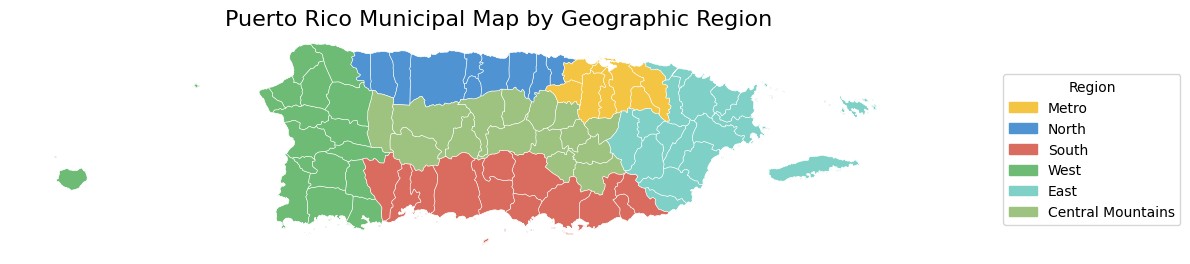

In [19]:
region_map_png = analysis_dir / "phase6_map_regions.png"

region_colors = {
    "Metro": "#f4c542",
    "North": "#4f93d2",
    "South": "#d96b5f",
    "West": "#6dbb75",
    "East": "#7fd1c8",
    "Central Mountains": "#9ec27f",
}

if MAP_BACKEND == "geopandas" and map_gdf is not None:
    map_gdf["region_color"] = map_gdf["region"].map(region_colors)

    fig, ax = plt.subplots(figsize=(12, 8))
    map_gdf.plot(
        ax=ax,
        color=map_gdf["region_color"].fillna("#d9d9d9"),
        edgecolor="white",
        linewidth=0.4,
    )
    ax.set_title("Puerto Rico Municipal Map by Geographic Region", fontsize=16)
    ax.axis("off")

    import matplotlib.patches as mpatches
    handles = [mpatches.Patch(color=color, label=region) for region, color in region_colors.items()]
    ax.legend(handles=handles, title="Region", loc="lower left", bbox_to_anchor=(1.01, 0.1))
    plt.tight_layout()
    plt.savefig(region_map_png, dpi=200, bbox_inches="tight")
    print(f"Saved: {region_map_png}")
    plt.show()
elif MAP_BACKEND == "geojson_fallback" and map_df is not None:
    plot_geojson_map(
        map_df,
        value_col="region",
        categorical=True,
        category_colors=region_colors,
        title="Puerto Rico Municipal Map by Geographic Region",
        save_path=region_map_png,
    )
else:
    print("Region map skipped because no spatial backend is available.")


Saved: phase6_map_region_systems.png


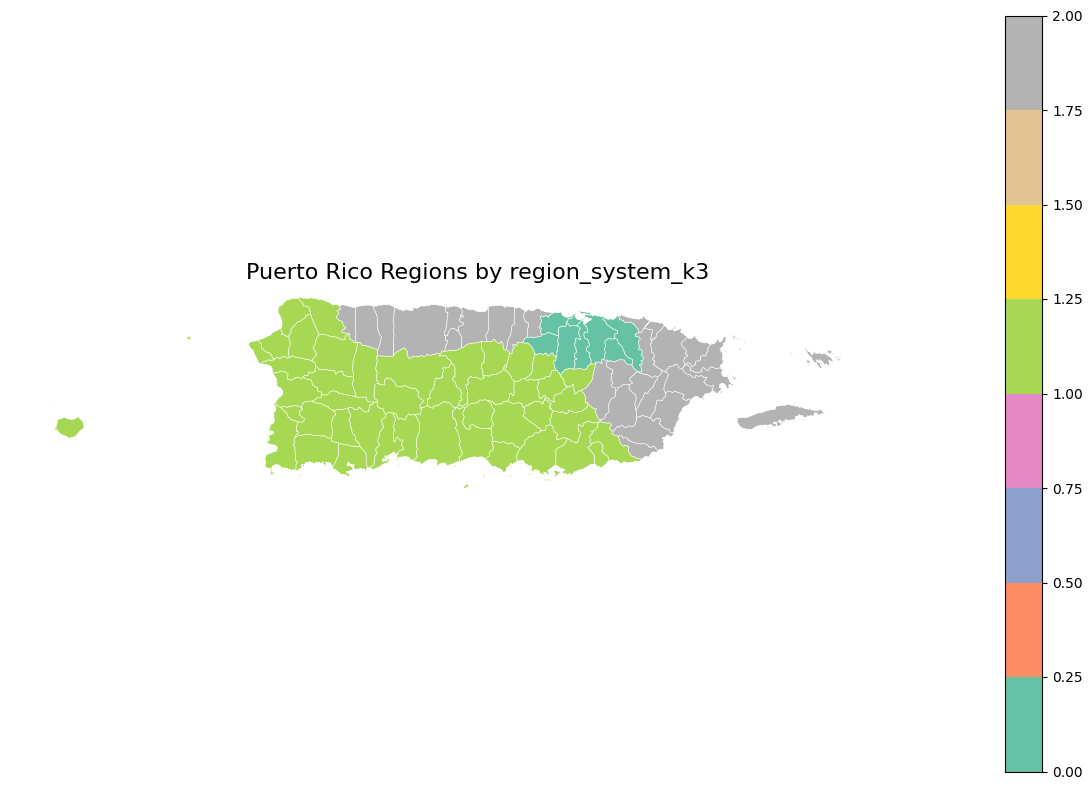

In [20]:
region_system_map_png = analysis_dir / "phase6_map_region_systems.png"

if MAP_BACKEND == "geopandas" and map_gdf is not None:
    fig, ax = plt.subplots(figsize=(12, 8))
    map_gdf.plot(
        column=region_system_col,
        cmap="Set2",
        linewidth=0.4,
        edgecolor="white",
        legend=True,
        ax=ax,
        missing_kwds={"color": "#d9d9d9", "label": "Missing"},
    )
    ax.set_title(f"Puerto Rico Regions by {region_system_col}", fontsize=16)
    ax.axis("off")
    plt.tight_layout()
    plt.savefig(region_system_map_png, dpi=200, bbox_inches="tight")
    print(f"Saved: {region_system_map_png}")
    plt.show()
elif MAP_BACKEND == "geojson_fallback" and map_df is not None:
    cats = sorted([x for x in map_df[region_system_col].dropna().unique()])
    palette = plt.cm.Set2(np.linspace(0, 1, max(len(cats), 1)))
    from matplotlib import colors as mcolors
    category_colors = {cat: mcolors.to_hex(palette[i]) for i, cat in enumerate(cats)}
    plot_geojson_map(
        map_df,
        value_col=region_system_col,
        categorical=True,
        category_colors=category_colors,
        title=f"Puerto Rico Regions by {region_system_col}",
        save_path=region_system_map_png,
    )
else:
    print("Region-system map skipped because no spatial backend is available.")


Saved: phase6_map_vulnerability.png


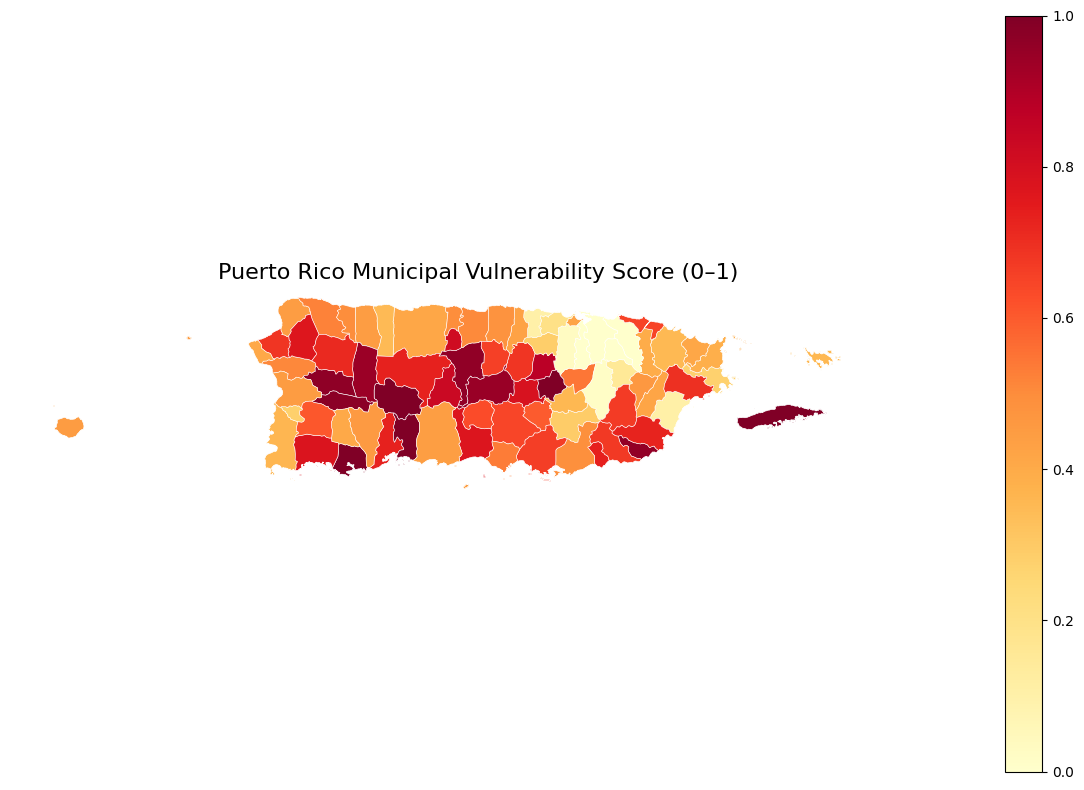

In [21]:
vulnerability_map_png = analysis_dir / "phase6_map_vulnerability.png"

if MAP_BACKEND == "geopandas" and map_gdf is not None and "vulnerability_score_0_1" in map_gdf.columns:
    fig, ax = plt.subplots(figsize=(12, 8))
    map_gdf.plot(
        column="vulnerability_score_0_1",
        cmap="YlOrRd",
        linewidth=0.4,
        edgecolor="white",
        legend=True,
        ax=ax,
        missing_kwds={"color": "#d9d9d9", "label": "Missing"},
    )
    ax.set_title("Puerto Rico Municipal Vulnerability Score (0–1)", fontsize=16)
    ax.axis("off")
    plt.tight_layout()
    plt.savefig(vulnerability_map_png, dpi=200, bbox_inches="tight")
    print(f"Saved: {vulnerability_map_png}")
    plt.show()
elif MAP_BACKEND == "geojson_fallback" and map_df is not None and "vulnerability_score_0_1" in map_df.columns:
    plot_geojson_map(
        map_df,
        value_col="vulnerability_score_0_1",
        categorical=False,
        cmap="YlOrRd",
        title="Puerto Rico Municipal Vulnerability Score (0–1)",
        save_path=vulnerability_map_png,
    )
else:
    print("Vulnerability map skipped because spatial or vulnerability data are unavailable.")


Saved: phase6_map_regions_labeled.png


/var/folders/nv/7vs_w8050fxbqxc7kvr45zpw0000gn/T/ipykernel_19377/2766568219.py:4: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  region_centroids = map_gdf.dissolve(by="region").centroid


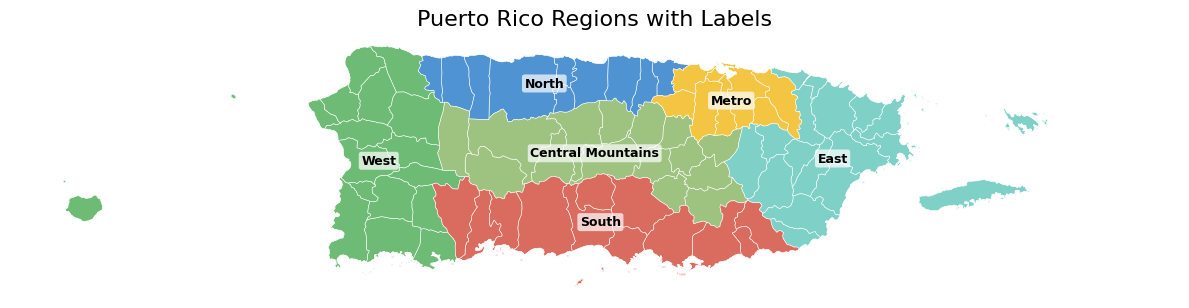

In [22]:
labeled_region_map_png = analysis_dir / "phase6_map_regions_labeled.png"

if MAP_BACKEND == "geopandas" and map_gdf is not None:
    region_centroids = map_gdf.dissolve(by="region").centroid

    fig, ax = plt.subplots(figsize=(12, 8))
    map_gdf.plot(
        ax=ax,
        color=map_gdf["region_color"].fillna("#d9d9d9") if "region_color" in map_gdf.columns else "#d9d9d9",
        edgecolor="white",
        linewidth=0.4,
    )

    for region, point in region_centroids.items():
        if point is not None and not point.is_empty:
            ax.text(
                point.x,
                point.y,
                region,
                fontsize=9,
                ha="center",
                va="center",
                weight="bold",
                color="black",
                bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.7),
            )

    ax.set_title("Puerto Rico Regions with Labels", fontsize=16)
    ax.axis("off")
    plt.tight_layout()
    plt.savefig(labeled_region_map_png, dpi=200, bbox_inches="tight")
    print(f"Saved: {labeled_region_map_png}")
    plt.show()
elif MAP_BACKEND == "geojson_fallback" and map_df is not None:
    plot_geojson_map(
        map_df,
        value_col="region",
        categorical=True,
        category_colors=region_colors,
        annotate_col="region",
        title="Puerto Rico Regions with Labels",
        save_path=labeled_region_map_png,
    )
else:
    print("Labeled region map skipped because no spatial backend is available.")


### Regional population change maps

These maps restore the region-level population change views from the original notebook while keeping the improved Phase 6 regional workflow.  
They summarize average municipal population change by region and annotate each region with its mean value.


Using population-change column for regional maps: lag_pop_change_1


,region,lag_pop_change_1,vulnerability_score_0_1
0,Central Mountains,-0.241778,0.748043
1,East,-0.139400,0.473188
2,Metro,-0.586042,0.117877
3,North,-0.206062,0.453714
4,South,-1.072356,0.647790
5,West,-0.633988,0.617930


Saved: phase6_map_region_pop_change.png


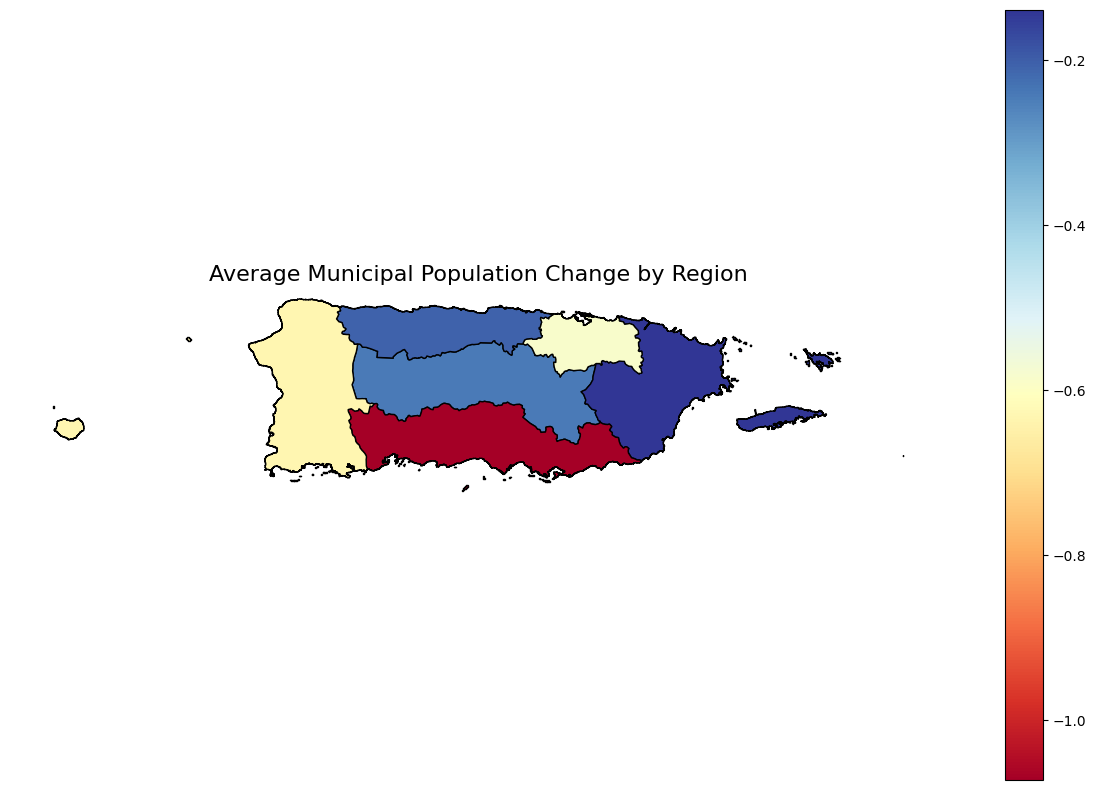

Saved: phase6_map_region_pop_change_labeled.png


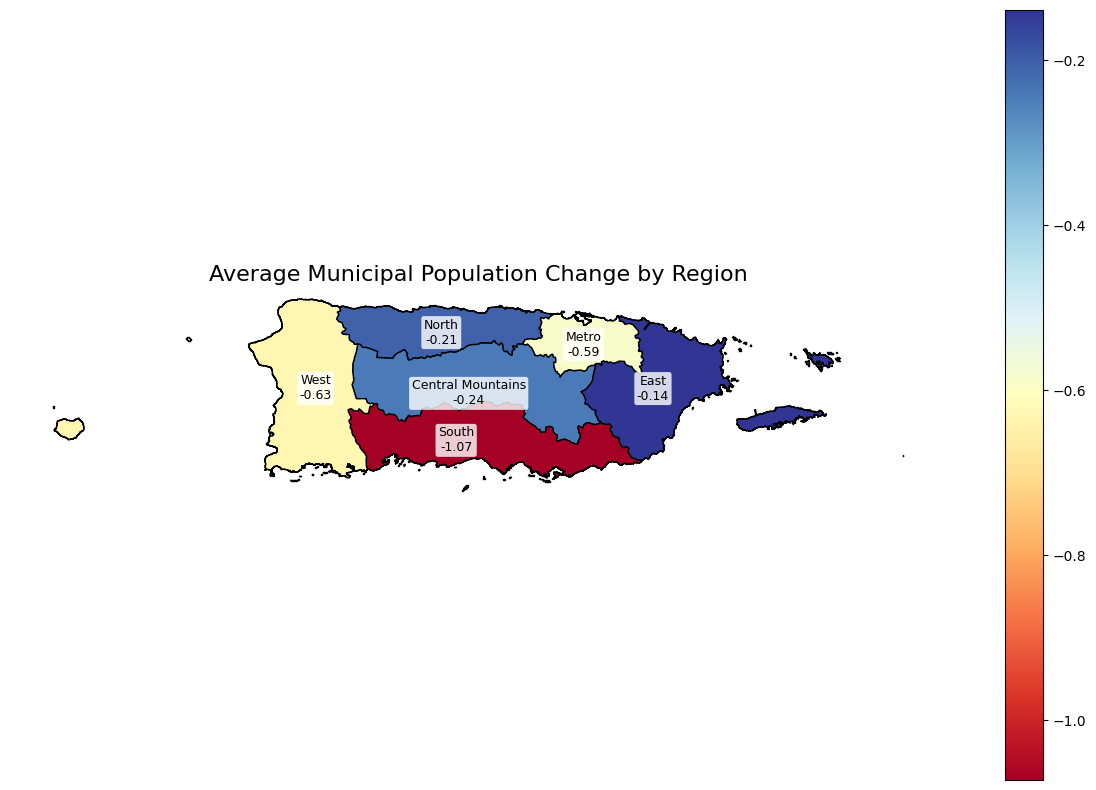

,region,lag_pop_change_1,vulnerability_score_0_1
4,South,-1.072356,0.647790
5,West,-0.633988,0.617930
2,Metro,-0.586042,0.117877
0,Central Mountains,-0.241778,0.748043
3,North,-0.206062,0.453714
1,East,-0.139400,0.473188


In [23]:
region_loss_gdf = None
region_loss_summary = None
region_pop_change_map_png = analysis_dir / "phase6_map_region_pop_change.png"
region_pop_change_labeled_png = analysis_dir / "phase6_map_region_pop_change_labeled.png"

# Prefer the original target column, but fall back gracefully if the latest-year export
# only carries a recent population-change proxy.
pop_change_col = None
for candidate in ["target_pop_change", "lag_pop_change_1", "lag_pop_change_2"]:
    if MAP_BACKEND == "geopandas" and map_gdf is not None and candidate in map_gdf.columns:
        pop_change_col = candidate
        break
    if MAP_BACKEND == "geojson_fallback" and map_df is not None and candidate in map_df.columns:
        pop_change_col = candidate
        break

if pop_change_col is None:
    raise ValueError(
        "Expected one of ['target_pop_change', 'lag_pop_change_1', 'lag_pop_change_2'] "
        "in the merged Phase 6 map data."
    )

print(f"Using population-change column for regional maps: {pop_change_col}")

if MAP_BACKEND == "geopandas" and map_gdf is not None:
    agg_map = {pop_change_col: "mean"}
    if "vulnerability_score_0_1" in map_gdf.columns:
        agg_map["vulnerability_score_0_1"] = "mean"

    region_loss_gdf = map_gdf.dissolve(by="region", aggfunc=agg_map).reset_index()

    keep_cols = ["region", pop_change_col]
    if "vulnerability_score_0_1" in region_loss_gdf.columns:
        keep_cols.append("vulnerability_score_0_1")
    display(region_loss_gdf[keep_cols])

    # Map 1: average municipal population change by region
    fig, ax = plt.subplots(figsize=(12, 8))
    region_loss_gdf.plot(
        column=pop_change_col,
        cmap="RdYlBu",
        linewidth=1.0,
        edgecolor="black",
        legend=True,
        ax=ax,
        missing_kwds={"color": "#d9d9d9", "label": "Missing"},
    )
    ax.set_title("Average Municipal Population Change by Region", fontsize=16)
    ax.axis("off")
    plt.tight_layout()
    plt.savefig(region_pop_change_map_png, dpi=200, bbox_inches="tight")
    print(f"Saved: {region_pop_change_map_png}")
    plt.show()

    # Map 2: same regional map with region names and values
    fig, ax = plt.subplots(figsize=(12, 8))
    region_loss_gdf.plot(
        column=pop_change_col,
        cmap="RdYlBu",
        linewidth=1.0,
        edgecolor="black",
        legend=True,
        ax=ax,
        missing_kwds={"color": "#d9d9d9", "label": "Missing"},
    )

    label_points = region_loss_gdf.geometry.representative_point()
    for (_, row), pt in zip(region_loss_gdf.iterrows(), label_points):
        if pt is not None and not pt.is_empty:
            ax.text(
                pt.x,
                pt.y,
                f"{row['region']}\n{row[pop_change_col]:.2f}",
                fontsize=9,
                ha="center",
                va="center",
                bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.8),
            )

    ax.set_title("Average Municipal Population Change by Region", fontsize=16)
    ax.axis("off")
    plt.tight_layout()
    plt.savefig(region_pop_change_labeled_png, dpi=200, bbox_inches="tight")
    print(f"Saved: {region_pop_change_labeled_png}")
    plt.show()

    region_loss_summary = region_loss_gdf[keep_cols].sort_values(pop_change_col)
    display(region_loss_summary)

elif MAP_BACKEND == "geojson_fallback" and map_df is not None:
    agg_dict = {pop_change_col: "mean"}
    if "vulnerability_score_0_1" in map_df.columns:
        agg_dict["vulnerability_score_0_1"] = "mean"

    region_loss_summary = (
        map_df.groupby("region", dropna=False)
        .agg(agg_dict)
        .reset_index()
        .sort_values(pop_change_col)
    )
    display(region_loss_summary)

    # Fallback map 1: municipality-level choropleth using the same population-change field
    plot_geojson_map(
        map_df,
        value_col=pop_change_col,
        categorical=False,
        cmap="RdYlBu",
        title="Average Municipal Population Change by Region",
        save_path=region_pop_change_map_png,
    )

    # Fallback map 2: municipality-level choropleth with region labels
    plot_geojson_map(
        map_df,
        value_col=pop_change_col,
        categorical=False,
        cmap="RdYlBu",
        annotate_col="region",
        title="Average Municipal Population Change by Region",
        save_path=region_pop_change_labeled_png,
    )
else:
    print("Population change maps skipped because spatial or population-change data are unavailable.")


## 12. Export Phase 6 outputs

The notebook exports both municipality-level and region-level outputs so the results can feed directly into the dashboard, profile pages, or paper tables.


In [24]:
region_profile_out = analysis_dir / "phase6_region_profiles.csv"
region_cluster_counts_out = analysis_dir / "phase6_region_cluster_counts.csv"
region_cluster_shares_out = analysis_dir / "phase6_region_cluster_shares.csv"
region_system_profile_out = analysis_dir / "phase6_region_system_profiles.csv"
region_eval_out = analysis_dir / "phase6_region_system_diagnostics.csv"
region_crosswalk_out = analysis_dir / "phase6_region_phase5_crosswalk.csv"
summary_out = analysis_dir / "phase6_regional_summary.json"

region_profile.to_csv(region_profile_out, index=False)
region_cluster_counts.to_csv(region_cluster_counts_out)
region_cluster_shares.to_csv(region_cluster_shares_out)
region_system_profile.to_csv(region_system_profile_out)
region_cluster_eval.to_csv(region_eval_out, index=False)
region_crosswalk.to_csv(region_crosswalk_out, index=False)

if top_vulnerable_by_region is not None:
    top_vulnerable_by_region.to_csv(analysis_dir / "phase6_top_vulnerable_by_region.csv", index=False)

map_out = None
if MAP_BACKEND == "geopandas" and map_gdf is not None:
    map_out = analysis_dir / "phase6_regional_map.geojson"
    map_gdf.to_file(map_out, driver="GeoJSON")
    print(f"Saved: {map_out}")

if region_loss_summary is not None:
    region_loss_summary.to_csv(analysis_dir / "phase6_region_population_change_summary.csv", index=False)

map_outputs = {}
for name in [
    "region_map_png",
    "region_system_map_png",
    "vulnerability_map_png",
    "labeled_region_map_png",
    "region_pop_change_map_png",
    "region_pop_change_labeled_png",
]:
    p = globals().get(name)
    if p is not None:
        map_outputs[name] = str(p)

phase6_summary = {
    "phase5_typology_file": typology_path.name,
    "primary_phase5_cluster_column": primary_cluster_col,
    "detected_phase5_cluster_columns": cluster_cols,
    "missing_region_mappings": missing_region,
    "region_counts": region_counts.to_dict(),
    "profile_metric_cols": profile_metric_cols,
    "spatial_backend": MAP_BACKEND,
    "has_geopandas": bool(HAS_GEO),
    "geometry_file_used": str(geo_path) if geo_path is not None else None,
    "constant_region_cols_removed": constant_region_cols,
    "best_region_system_k_by_silhouette": best_region_k,
    "preferred_primary_region_system_k": preferred_region_k,
    "region_system_seed_stability": region_seed_stability,
    "adjacency_summary": adjacency_summary.to_dict(orient="records") if hasattr(adjacency_summary, "to_dict") else adjacency_summary,
    "moran_summary": moran_summary,
    "map_outputs": map_outputs,
    "regional_geojson_output": str(map_out) if map_out is not None else None,
}

with open(summary_out, "w") as f:
    json.dump(phase6_summary, f, indent=4)

print(f"Saved: {region_profile_out}")
print(f"Saved: {region_cluster_counts_out}")
print(f"Saved: {region_cluster_shares_out}")
print(f"Saved: {region_system_profile_out}")
print(f"Saved: {region_eval_out}")
print(f"Saved: {region_crosswalk_out}")
print(f"Saved: {summary_out}")
if map_outputs:
    print("Saved map images:")
    for k, v in map_outputs.items():
        print(f"  - {k}: {v}")


Saved: phase6_regional_map.geojson
Saved: phase6_region_profiles.csv
Saved: phase6_region_cluster_counts.csv
Saved: phase6_region_cluster_shares.csv
Saved: phase6_region_system_profiles.csv
Saved: phase6_region_system_diagnostics.csv
Saved: phase6_region_phase5_crosswalk.csv
Saved: phase6_regional_summary.json
Saved map images:
  - region_map_png: phase6_map_regions.png
  - region_system_map_png: phase6_map_region_systems.png
  - vulnerability_map_png: phase6_map_vulnerability.png
  - labeled_region_map_png: phase6_map_regions_labeled.png
  - region_pop_change_map_png: phase6_map_region_pop_change.png
  - region_pop_change_labeled_png: phase6_map_region_pop_change_labeled.png


# Phase 6 Conclusion: Regional Systems, Spatial Coherence, and Cross-Scale Structure

Phase 6 should be understood as a **regional interpretation and validation layer** built directly on top of the municipal typology results from Phase 5.

A central improvement in this revised notebook is that it no longer treats regional analysis as a stand-alone exercise. Instead, it explicitly carries forward the preferred municipal cluster solution, vulnerability score, and typology structure from Phase 5. This makes it possible to ask how municipal typologies organize spatially, rather than simply redefining clusters at a different scale.

The notebook also makes the definition of region fully explicit. Geographic regions are assigned using a fixed municipality-to-region mapping, and these named regions are then profiled using municipal averages and cluster shares. This distinction matters because the estimated **region systems** are not substitutes for geography; they are higher-level structural summaries of those geographic regions.

Another key improvement is that the region-level systems are now validated rather than assumed. The workflow uses standardized region profiles, silhouette diagnostics, cluster-size checks, and seed-stability tests before selecting a preferred primary solution. As in Phase 5, a slightly better silhouette score is not treated as decisive when it depends on a more fragmented structure.

The notebook also adds a basic spatial coherence layer. By merging the regional and typology outputs back onto municipality geometry, it can evaluate whether adjacent municipalities tend to share the same region, municipal typology, or broader region system. When optional spatial packages are available, the notebook can also assess whether vulnerability exhibits positive spatial autocorrelation.

Substantively, this phase should still be presented as a **descriptive regional classification layer rather than a causal model**. Its main value is that it helps organize Puerto Rico's municipalities into broader geographic and structural systems that can support map interpretation, dashboard storytelling, case selection, and policy framing. In combination with Phases 2 through 5, Phase 6 shows that even when forecasting performance is limited, meaningful structural heterogeneity can still be recovered at both the municipal and regional scales.
